In [3]:
import parselmouth
import matplotlib.pyplot as plt
from audiochains.streams import StreamFromFile
from audiochains.block_methods import UnpackRawInFloat32
import numpy as np
import time as t  # Переименование модуля time

from kiwisolver import strength

In [4]:

def process_audio(
    audio_file,                  # Путь к аудиофайлу
    praat_file=None,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=75,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.03,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=512,               # Размер блока
    plot_results=True            # Построить график
):
    """
    Функция для обработки аудио с использованием методов Parselmouth.
    """
    # Локальные переменные для результатов
    times = []
    frequencies = []
    praat_times = []
    praat_frequencies = []
    processing_times = []

    # Если указан файл Praat, читаем его данные
    if praat_file:
        try:
            with open(praat_file, 'r') as f:
                next(f)  # Пропускаем заголовок
                for line in f:
                    time, freq = line.strip().split()
                    time = float(time)
                    freq = float(freq) if freq != '--undefined--' else np.nan
                    praat_times.append(time)
                    praat_frequencies.append(freq)
        except Exception as e:
            print(f"Ошибка при чтении файла {praat_file}: {e}")

    # Обработка аудиофайла
    with StreamFromFile(
        filename=audio_file,
        blocksize=blocksize
    ) as stream:
        print(f"Частота дискретизации: {stream.samplerate} Гц")
        stream.set_methods(UnpackRawInFloat32())
        current_time = 0

        for i in range(stream.get_iterations()):
            try:
                raw_data = stream.read(blocksize)
                if not raw_data:
                    print(f"Блок {i} пустой, пропускаем...")
                    continue

                # Измеряем время начала обработки
                start_time = t.time()

                signal = stream.chain_of_methods(raw_data)
                sound = parselmouth.Sound(values=signal, sampling_frequency=stream.samplerate)

                # Выбор метода
                if method == "ac":
                    pitch = sound.to_pitch_ac(
                        time_step=time_step,
                        pitch_floor=pitch_floor,
                        pitch_ceiling=pitch_ceiling,
                        silence_threshold=silence_threshold,
                        voicing_threshold=voicing_threshold,
                        octave_cost=octave_cost,
                        octave_jump_cost=octave_jump_cost,
                        voiced_unvoiced_cost=voiced_unvoiced_cost
                    )
                elif method == "cc":
                    pitch = sound.to_pitch_cc(
                        time_step=time_step,
                        pitch_floor=pitch_floor,
                        pitch_ceiling=pitch_ceiling,
                        silence_threshold=silence_threshold,
                        voicing_threshold=voicing_threshold,
                        octave_cost=octave_cost,
                        octave_jump_cost=octave_jump_cost,
                        voiced_unvoiced_cost=voiced_unvoiced_cost
                    )
                else:
                    raise ValueError(f"Неизвестный метод: {method}. Используйте 'ac' или 'cc'.")

                frequency = pitch.selected_array['frequency']
                frequency[frequency == 0] = np.nan
                times.extend(current_time + pitch.xs())
                frequencies.extend(frequency)
                current_time += blocksize / stream.samplerate
                # Измеряем время окончания обработки и рассчитываем разницу
                end_time = t.time()
                processing_times.append(end_time - start_time)


            except Exception as err:
                print(f"Ошибка при обработке блока {i}: {err}")

    # Вычисление среднего времени обработки одного блока
    if processing_times:
        avg_processing_time = sum(processing_times) / len(processing_times)
        print(f"Среднее время обработки одного блока ({blocksize} сэмплов): {avg_processing_time:.6f} секунд")
    else:
        print("Обработка не производилась, данные отсутствуют.")
    
    # Построение графика
    if plot_results and times and frequencies:
        plt.figure(figsize=(12, 8))

        # График для Parselmouth
        plt.plot(times, frequencies, label=f"Основной тон ({method})", color="blue")

        # График для файла Praat (если есть данные)
        if praat_times and praat_frequencies:
            plt.plot(praat_times, praat_frequencies, label="Основной тон (Praat)", color="red", linestyle="--")

        plt.xlabel("Время (с)")
        plt.ylabel("Частота (Гц)")
        plt.title("График основного тона")
        plt.legend()
        plt.grid()
        plt.show()
    else:
        print("Данные для построения графика отсутствуют.")

    # Возврат результатов
    return times, frequencies, praat_times, praat_frequencies


### **Чистый звук автокорреляция**

Частота дискретизации: 16000 Гц
Среднее время обработки одного блока (1024 сэмплов): 0.000272 секунд


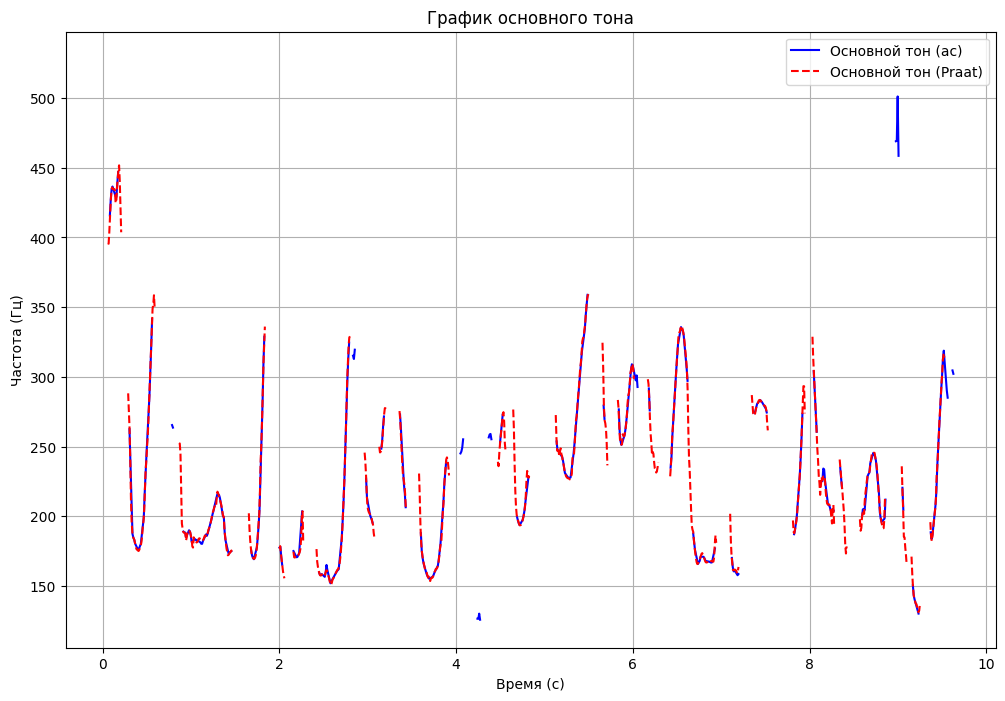

In [19]:
audio1 = 'silero_vad/files/femalechist2.wav' #женский голос без шумов
praat1 = 'silero_vad/files/praatfemalechist.txt' #женский голос без шумов

process_audio(
    audio1,                  # Путь к аудиофайлу
    praat_file=praat1,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=95,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.4,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=1024,               # Размер блока
    plot_results=True            # Построить график
);

### **Слегка белый шум автокорреляция**

Частота дискретизации: 16000 Гц
Среднее время обработки одного блока (1024 сэмплов): 0.000232 секунд


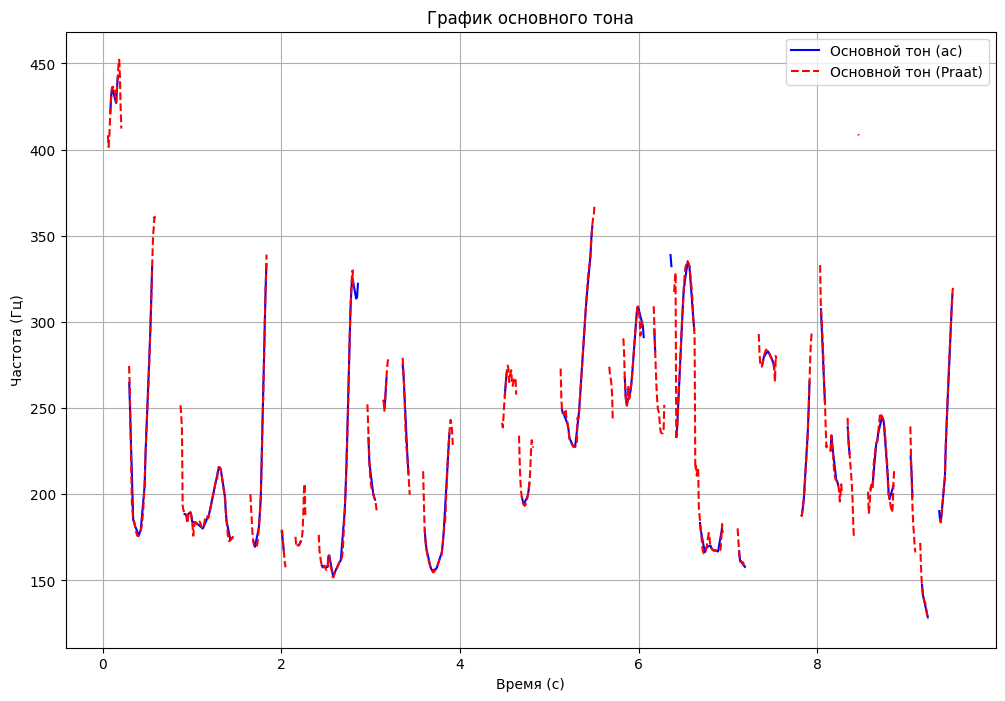

In [52]:
audio2 = 'silero_vad/files/femalenechist2.wav' #женский голос с шумами
praat2 = 'silero_vad/files/praat2nechist.txt' #женский голос с шумами

process_audio(
    audio2,                  # Путь к аудиофайлу
    praat_file=praat2,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=75,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.4,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=1024,               # Размер блока
    plot_results=True            # Построить график
);

### **0,1 ДБ белый шум автокорреляция**

Частота дискретизации: 16000 Гц
Среднее время обработки одного блока (1024 сэмплов): 0.000317 секунд


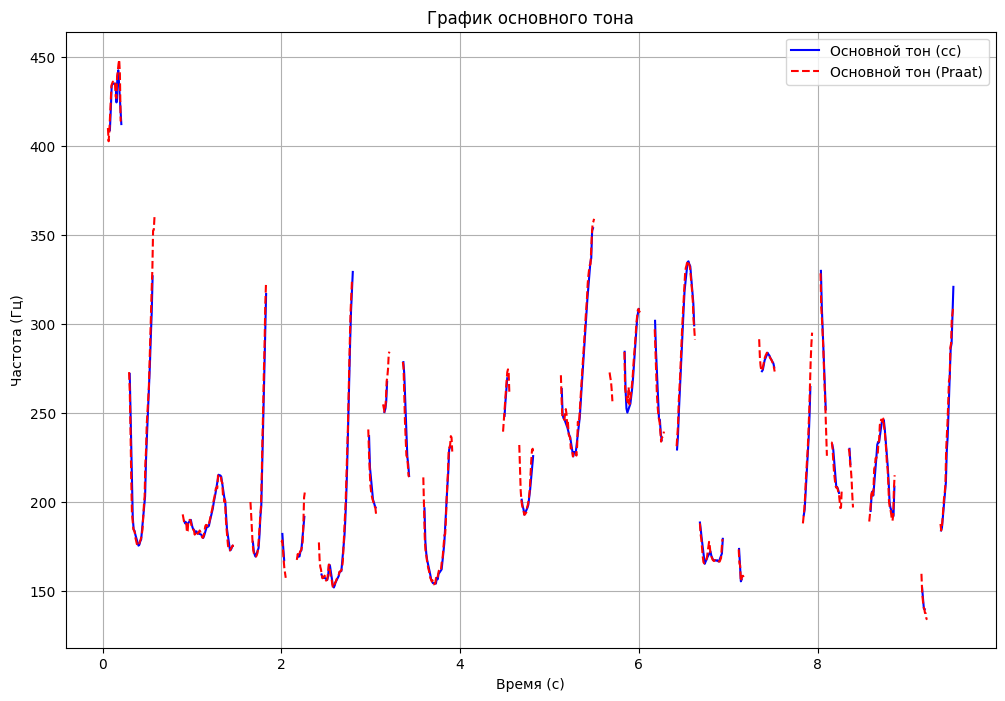

In [55]:
audio3 = 'silero_vad/files/femalesovsemnechist2.wav' #женский голос с шумами
praat3 = 'silero_vad/files/praatsovsemnechist2.txt' #женский голос с шумам

process_audio(
    audio3,                  # Путь к аудиофайлу
    praat_file=praat3,             # Путь к файлу Praat
    method="cc",                 # Метод: "ac" или "cc"
    pitch_floor=75,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.4,      # Порог тишины
    voicing_threshold=0.5,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=1024,               # Размер блока
    plot_results=True            # Построить график
);

### **0,1 ДБ розовый шум автокорреляция**

Частота дискретизации: 16000 Гц
Среднее время обработки одного блока (1024 сэмплов): 0.000186 секунд


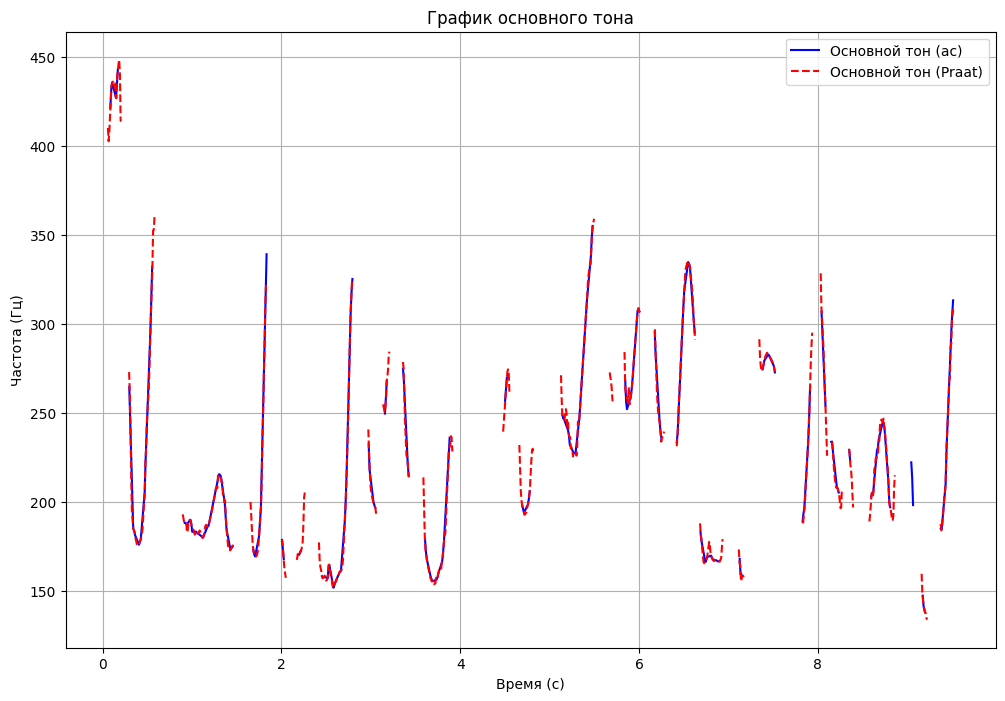

In [58]:
audio4 = 'silero_vad/files/rozoviifemalenechist2.wav' #женский голос с шумами
praat4 = 'silero_vad/files/praatrozovienechishtfem2.txt' #женский голос с шумами

process_audio(
    audio4,                  # Путь к аудиофайлу
    praat_file=praat4,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=75,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.4,      # Порог тишины
    voicing_threshold=0.5,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=1024,               # Размер блока
    plot_results=True            # Построить график
);

### **0,1 ДБ коричневый шум автокорреляция**

Частота дискретизации: 16000 Гц
Среднее время обработки одного блока (1024 сэмплов): 0.000214 секунд


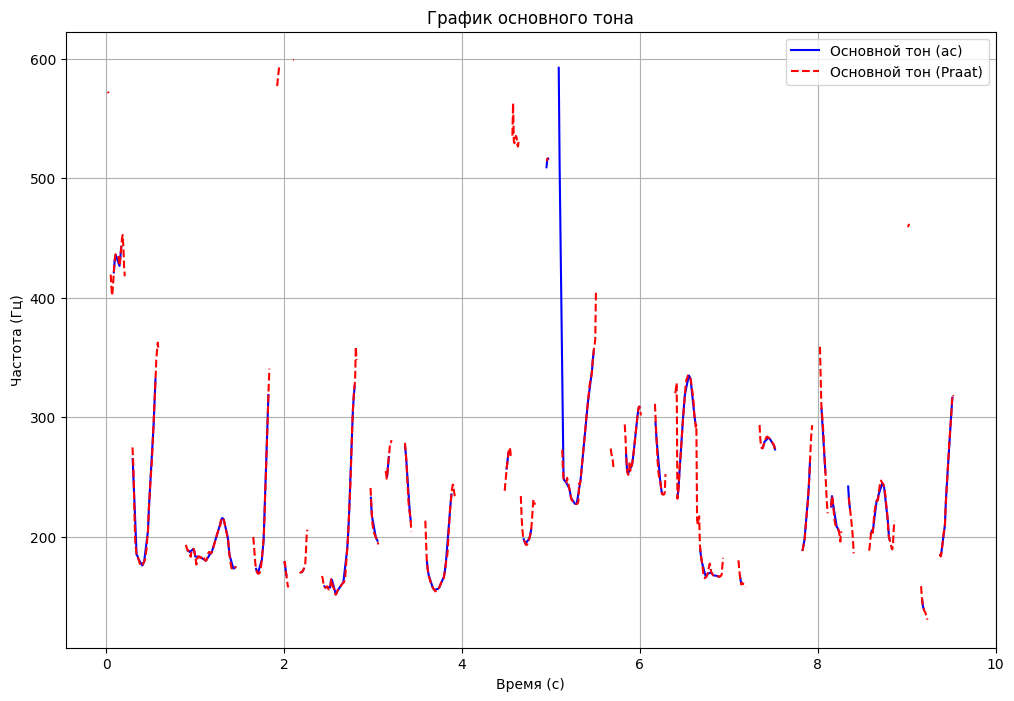

In [9]:
audio5 = 'silero_vad/files/сorichfemalenechist2.wav' #женский голос с шумами
praat5 = 'silero_vad/files/praarcorichnechist2.txt' #женский голос c шумами

process_audio(
    audio5,                  # Путь к аудиофайлу
    praat_file=praat5,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=75,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.4,      # Порог тишины
    voicing_threshold=0.5,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=1024,               # Размер блока
    plot_results=True            # Построить график
);

### **Смотрим, как влияет белый шум на графики из Praat**

In [54]:

def plot_praat_files(praat_files):
    """
    Функция для построения графиков частоты основного тона из нескольких файлов Praat.
    :param praat_files: Список путей к файлам Praat.
    """
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']  # Цвета для графиков
    linestyles = ['-', '--', '-.', ':']  # Линии для различия между графиками

    plt.figure(figsize=(12, 8))  # Создаем фигуру для графика

    for idx, praat_file in enumerate(praat_files):
        praat_times = []
        praat_frequencies = []

        # Чтение файла Praat
        try:
            with open(praat_file, 'r') as f:
                next(f)  # Пропускаем заголовок
                for line in f:
                    time, freq = line.strip().split()
                    time = float(time)
                    freq = float(freq) if freq != '--undefined--' else np.nan
                    praat_times.append(time)
                    praat_frequencies.append(freq)
        except Exception as e:
            print(f"Ошибка при чтении файла {praat_file}: {e}")
            continue  # Переходим к следующему файлу, если текущий не удалось прочитать

        # Построение графика, если данные есть
        if praat_times and praat_frequencies:
            color = colors[idx % len(colors)]  # Выбираем цвет (по кругу)
            linestyle = linestyles[idx % len(linestyles)]  # Выбираем стиль линии (по кругу)
            label = f"Praat File {idx + 1}"  # Создаем метку для легенды
            plt.plot(praat_times, praat_frequencies, label=label, color=color, linestyle=linestyle)

    # Настройка графика
    plt.xlabel("Время (с)")
    plt.ylabel("Частота (Гц)")
    plt.title("График частоты основного тона из файлов Praat")
    plt.legend()
    plt.grid()
    plt.show()


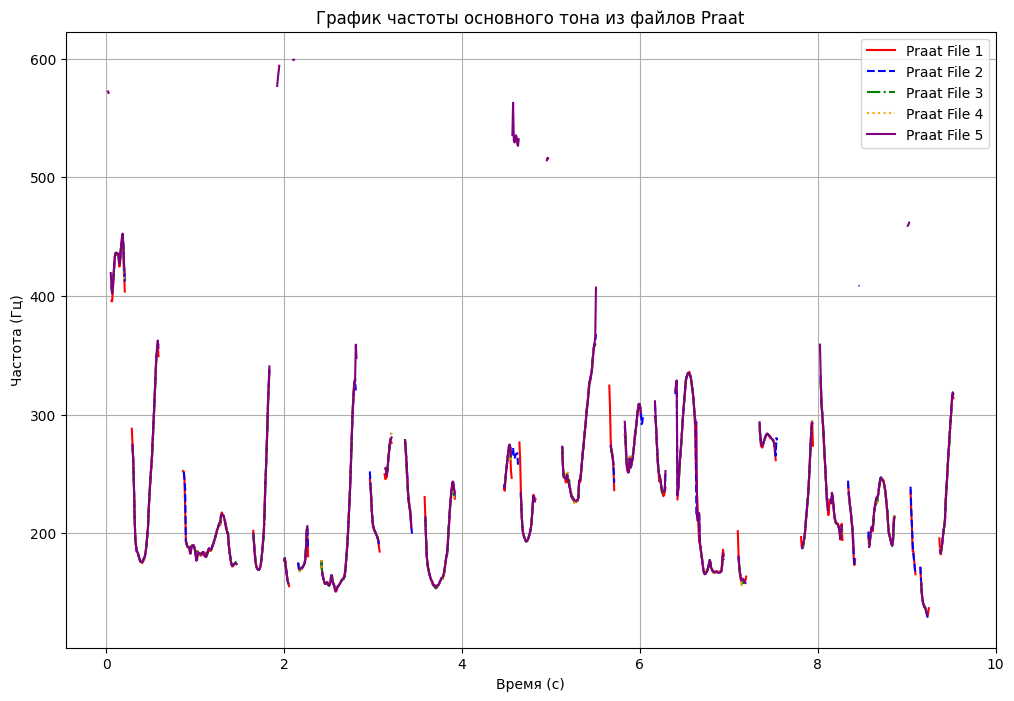

In [63]:


praat_files = [praat1, praat2, praat3, praat4, praat5]

# Вызов функции
plot_praat_files(praat_files)
#hello

## **Ребенок говорит**

Частота дискретизации: 16000 Гц
Ошибка при обработке блока 154: To analyse this Sound, “minimum pitch” must not be less than 250 Hz.
Sound: pitch analysis not performed.
Среднее время обработки одного блока (1024 сэмплов): 0.000243 секунд


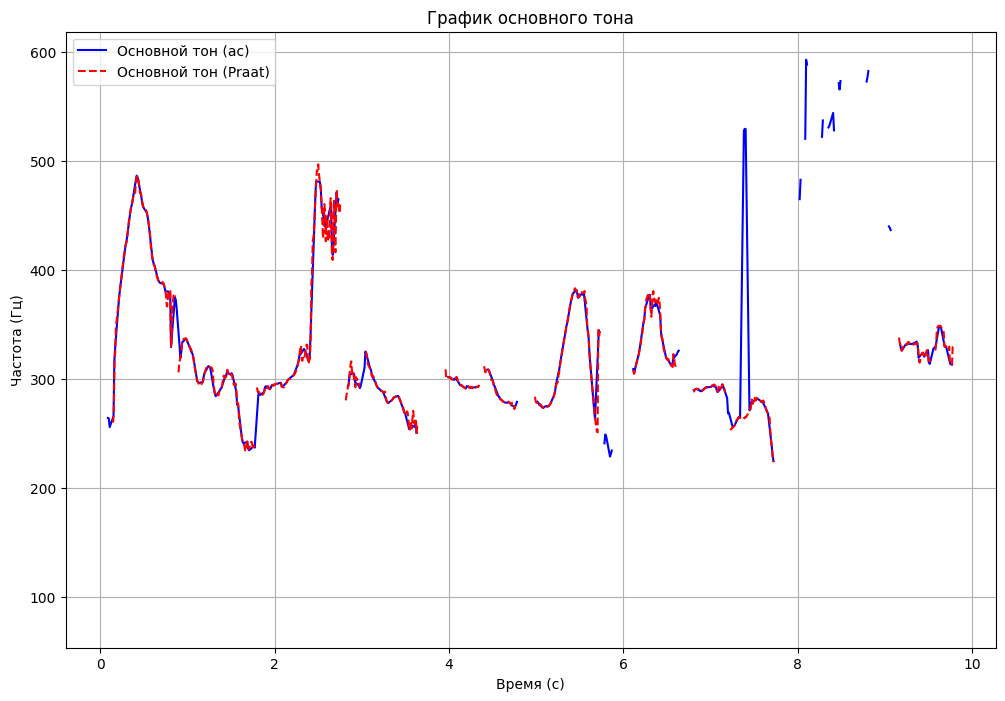

In [16]:
audio6 = 'silero_vad/files/rebenok1mono.wav' 
praat6 = 'silero_vad/files/rebenokpitch.txt' 

process_audio(
    audio6,                  # Путь к аудиофайлу
    praat_file=praat6,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=75,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.03,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=1024,               # Размер блока
    plot_results=True            # Построить график
);

Частота дискретизации: 16000 Гц
Среднее время обработки одного блока (1024 сэмплов): 0.000430 секунд


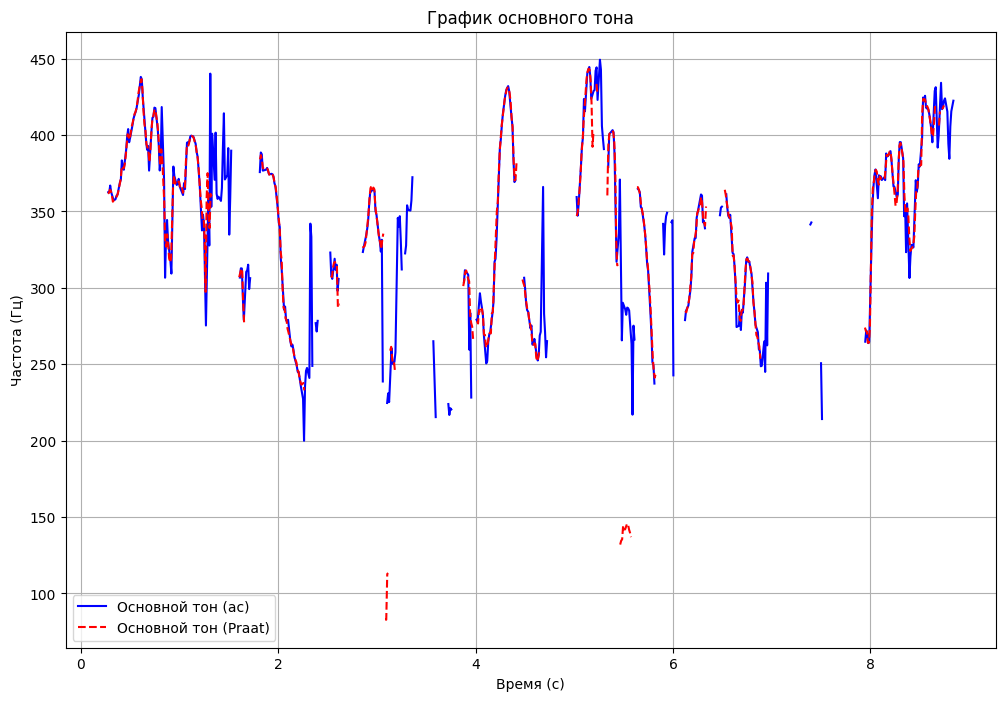

In [27]:
audio7 = 'silero_vad/files/stixeseninmono.wav' 
praat7 = 'silero_vad/files/prstixesenintxt' 

process_audio(
    audio7,                  # Путь к аудиофайлу
    praat_file=praat7,             # Путь к файлу Praat
    method="ac",                 # Метод: "ac" или "cc"
    pitch_floor=200,              # Минимальная частота
    pitch_ceiling=600,           # Максимальная частота
    time_step=0.01,              # Шаг анализа
    silence_threshold=0.03,      # Порог тишины
    voicing_threshold=0.45,      # Порог озвучивания
    octave_cost=0.01,            # Стоимость отклонения на октаву
    octave_jump_cost=0.35,       # Стоимость скачка на октаву
    voiced_unvoiced_cost=0.14,   # Стоимость перехода между озвученным и неозвученным
    blocksize=1024,               # Размер блока
    plot_results=True            # Построить график
);